In [1]:
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn

from utils import build_library_balanced
from utils import rnd_series
from utils import make_gid_from_available

from utils_models import normalize_df
from utils_models import pack_inputs

from datasets import sample_collocation_balanced
from datasets import sample_terminal_balanced
from datasets import sample_boundary_balanced
from datasets import build_validation_mc_balanced


from model1_MLP import MLP
from model1_MLP import pde_residual
from model1_MLP import minibatch

from evaluation import evaluate_pinn_vs_mc

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.float_format", "{:,.4f}".format)



# PARAMETERS

np.random.seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUT_DIR = "./dataset_asian_wti_balanced"
os.makedirs(OUT_DIR, exist_ok=True)

RISK_FREE = 0.02
AVG_BUSINESS_DAYS = 20

# Dataset sizes
N_LIBRARY        = 3000
N_COLLOCATION    = 200_000
N_TERMINAL       = 25_000
N_BOUNDARY       = 20_000
N_VALIDATION_MC  = 1_000

# Parameter ranges
F0_RANGE         = (40.0, 110.0)
MONEY_RANGE      = (0.5, 1.5)     # K / F0
SIGMA_RANGE      = (0.15, 0.60)
R_RANGE          = (0.00, 0.05)

# Model's parameters
HIDDEN = 256
LAYERS = 5
LR = 1e-3
EPOCHS = 3000
BATCH_C = 2048
BATCH_T = 512
BATCH_B = 512
ALPHA, BETA, GAMMA = 1.0, 2.0, 1.0
GRAD_CLIP = 1.0



# DATASET CONSTRUCTION 

print("Building balanced trajectory library...")
df_lib = build_library_balanced()

print("Sampling datasets for PINN training...")
df_coll = sample_collocation_balanced(df_lib, n=N_COLLOCATION)
df_term = sample_terminal_balanced(df_lib, n=N_TERMINAL)
df_bdry = sample_boundary_balanced(df_lib, n=N_BOUNDARY)

print("Building balanced validation set (Monte Carlo)...")
df_val = build_validation_mc_balanced(n=N_VALIDATION_MC)

Building balanced trajectory library...
Sampling datasets for PINN training...
Building balanced validation set (Monte Carlo)...
Calcolo prezzi Monte Carlo bilanciati...


## VALIDATION DATASET

In [23]:
df_val

,F0,K,r,sigma,T_years,price_mc
0,87.3690,111.9794,0.0263,0.3021,0.0794,0.0000
1,87.4144,63.6301,0.0183,0.1548,0.0794,23.7142
2,77.2102,58.7469,0.0168,0.4923,0.0794,18.5162
3,106.0564,115.7505,0.0269,0.2946,0.0794,0.0692
4,81.0104,70.9330,0.0067,0.2191,0.0794,10.0202
...,...,...,...,...,...,...
995,71.0310,53.2679,0.0378,0.5256,0.0794,17.7223
996,55.5463,74.3806,0.0221,0.2971,0.0794,0.0000
997,61.1284,87.5374,0.0368,0.3663,0.0794,0.0000
998,55.2587,58.3478,0.0306,0.2282,0.0794,0.0610


=== STRUCTURAL CHECKS ===
        F0        K      r  sigma  T_years  price_mc
0  87.3690 111.9794 0.0263 0.3021   0.0794    0.0000
1  87.4144  63.6301 0.0183 0.1548   0.0794   23.7142
2  77.2102  58.7469 0.0168 0.4923   0.0794   18.5162
3 106.0564 115.7505 0.0269 0.2946   0.0794    0.0692
4  81.0104  70.9330 0.0067 0.2191   0.0794   10.0202
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   F0        1000 non-null   float64
 1   K         1000 non-null   float64
 2   r         1000 non-null   float64
 3   sigma     1000 non-null   float64
 4   T_years   1000 non-null   float64
 5   price_mc  1000 non-null   float64
dtypes: float64(6)
memory usage: 47.0 KB
None
              F0          K          r      sigma    T_years   price_mc
count 1,000.0000 1,000.0000 1,000.0000 1,000.0000 1,000.0000 1,000.0000
mean     75.3462    74.2281     0.0246     0.3747

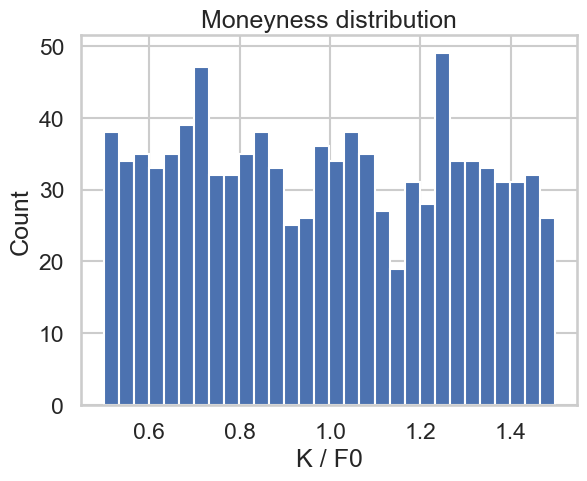


=== SLICE TEST (fixed sigma & r) ===


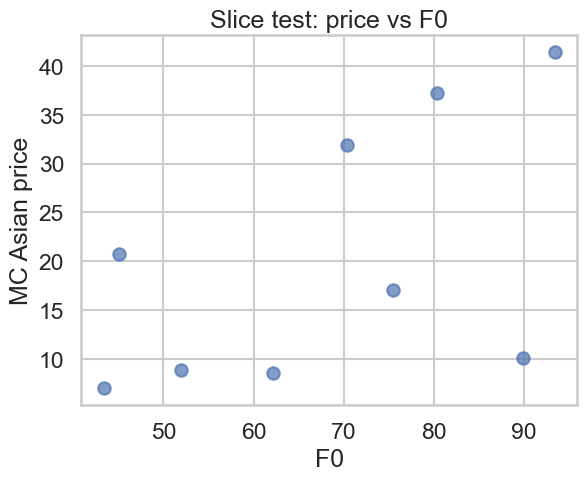


=== VARIANCE CHECK ===
Variance(price_mc) = 175.037851

✔ DATASET PASSED ALL INSPECTION CHECKS


In [22]:
import numpy as np
import matplotlib.pyplot as plt

def inspect_validation_dataset(df_val):
    print("=== STRUCTURAL CHECKS ===")
    print(df_val.head())
    print(df_val.info())
    print(df_val.describe())

    assert not df_val.isna().any().any(), "NaNs found in dataset"
    print("✔ No NaNs")

    print("\n=== RANGE CHECKS ===")
    for col in ["F0", "K", "sigma", "r", "T_years"]:
        print(f"{col}: min={df_val[col].min():.4f}, max={df_val[col].max():.4f}")

    print("\n=== ECONOMIC CONSISTENCY CHECKS ===")
    assert (df_val["price_mc"] >= 0).all(), "Negative prices found"
    print("✔ Prices are non-negative")

    corr_F0 = df_val["F0"].corr(df_val["price_mc"])
    corr_sigma = df_val["sigma"].corr(df_val["price_mc"])
    corr_m = (df_val["K"] / df_val["F0"]).corr(df_val["price_mc"])

    print(f"Corr(price, F0)     = {corr_F0:.3f} (expected > 0)")
    print(f"Corr(price, sigma)  = {corr_sigma:.3f} (expected > 0)")
    print(f"Corr(price, K/F0)   = {corr_m:.3f} (expected < 0)")

    print("\n=== DISTRIBUTION CHECKS ===")
    moneyness = df_val["K"] / df_val["F0"]
    print(moneyness.describe())

    plt.figure()
    plt.hist(moneyness, bins=30)
    plt.title("Moneyness distribution")
    plt.xlabel("K / F0")
    plt.ylabel("Count")
    plt.show()

    print("\n=== SLICE TEST (fixed sigma & r) ===")
    slice_df = df_val[
        (df_val["sigma"].between(df_val["sigma"].quantile(0.45),
                                  df_val["sigma"].quantile(0.55))) &
        (df_val["r"].between(df_val["r"].quantile(0.45),
                              df_val["r"].quantile(0.55)))
    ]

    plt.figure()
    plt.scatter(slice_df["F0"], slice_df["price_mc"], alpha=0.7)
    plt.xlabel("F0")
    plt.ylabel("MC Asian price")
    plt.title("Slice test: price vs F0")
    plt.show()

    print("\n=== VARIANCE CHECK ===")
    var_price = df_val["price_mc"].var()
    print(f"Variance(price_mc) = {var_price:.6f}")
    assert var_price > 0, "Degenerate dataset (zero variance)"

    print("\n✔ DATASET PASSED ALL INSPECTION CHECKS")


# USAGE:
inspect_validation_dataset(df_val)


# Exploratory Data Analysis

In [2]:
# 1) TRAJECTORIES (F(τ), A(τ))
df_traj = df_coll.copy()

# Build a local F0 proxy if missing 
if "F0_local" not in df_traj.columns:
    gkey = (
        rnd_series(df_traj.get("K", pd.Series(index=df_traj.index)), 1).astype(str) + "|" +
        rnd_series(df_traj.get("sigma", pd.Series(index=df_traj.index)), 3).astype(str) + "|" +
        rnd_series(df_traj.get("r", pd.Series(index=df_traj.index)), 3).astype(str)
    )

    df_tmp = df_traj.assign(_gkey=gkey)
    idx_max_tau = df_tmp.groupby("_gkey")["tau"].idxmax()
    F0_map = df_tmp.loc[idx_max_tau, ["_gkey", "F"]].set_index("_gkey")["F"]
    df_traj["F0_local"] = F0_map.reindex(df_tmp["_gkey"]).values

# Build trajectory group id
cols_specs = [
    ("F0_local", 2),
    ("K", 1),
    ("sigma", 3),
    ("r", 3),
    ("path_id", 0),
]
df_traj["gid"] = make_gid_from_available(df_traj, cols_specs)

# Keep only sufficiently dense trajectories
group_sizes = df_traj.groupby("gid")["tau"].nunique()
TOP_N = 200
MIN_TAU_PTS = 6
valid_gids = group_sizes[group_sizes >= MIN_TAU_PTS].head(TOP_N).index
df_traj = df_traj[df_traj["gid"].isin(valid_gids)].copy()

# 1a) F vs τ
fig_traj_F = go.Figure()
for gid, g in df_traj.groupby("gid"):
    g = g.sort_values("tau")
    fig_traj_F.add_trace(go.Scatter(
        x=g["tau"], y=g["F"], mode="lines",
        hovertext=[
            f"gid={gid}<br>tau={t:.5f}<br>F={fv:.3f}<br>A={av:.3f}"
            for t, fv, av in zip(g["tau"], g["F"], g["A"])
        ],
        hoverinfo="text",
        showlegend=False
    ))
fig_traj_F.update_layout(title="Trajectories: F vs τ", xaxis_title="τ", yaxis_title="F")
fig_traj_F.show()

# 1b) A vs τ
fig_traj_A = go.Figure()
for gid, g in df_traj.groupby("gid"):
    g = g.sort_values("tau")
    fig_traj_A.add_trace(go.Scatter(
        x=g["tau"], y=g["A"], mode="lines",
        hovertext=[
            f"gid={gid}<br>tau={t:.5f}<br>F={fv:.3f}<br>A={av:.3f}"
            for t, fv, av in zip(g["tau"], g["F"], g["A"])
        ],
        hoverinfo="text",
        showlegend=False
    ))
fig_traj_A.update_layout(title="Trajectories: A vs τ", xaxis_title="τ", yaxis_title="A")
fig_traj_A.show()

# 2) BOUNDARY LOCATION — (F, A)
dfb = df_bdry.copy()
F0_ref = dfb["F0_ref"].iloc[0] if "F0_ref" in dfb.columns and len(dfb) else dfb["F"].median()

low_ref, high_ref = 0.3 * F0_ref, 3.0 * F0_ref
tol = 0.05 * F0_ref

def edge_type(row):
    f, a = row.get("F"), row.get("A")
    d = {}
    if pd.notna(f):
        d["F-low"] = abs(f - low_ref)
        d["F-high"] = abs(f - high_ref)
    if pd.notna(a):
        d["A-low"] = abs(a - low_ref)
        d["A-high"] = abs(a - high_ref)
    if not d:
        return "Unknown"
    k = min(d, key=d.get)
    return k if d[k] <= tol else "Interior"

dfb["edge"] = dfb.apply(edge_type, axis=1)

fig_boundary = px.scatter(
    dfb, x="F", y="A", color="edge",
    title="Boundary points in (F, A)"
)

for v in [low_ref, high_ref]:
    fig_boundary.add_vline(x=v, line_dash="dot")
    fig_boundary.add_hline(y=v, line_dash="dot")

fig_boundary.update_layout(xaxis_title="F", yaxis_title="A")
fig_boundary.show()

# 3) BOUNDARY CHECK — V vs (A − K)

dfb["A_minus_K"] = pd.to_numeric(dfb["A"], errors="coerce") - pd.to_numeric(dfb["K"], errors="coerce")

fig_bcheck = go.Figure()
fig_bcheck.add_trace(go.Scatter(
    x=dfb["A_minus_K"], y=dfb["target_V"],
    mode="markers", name="Boundary points"
))

x_min, x_max = dfb["A_minus_K"].min(), dfb["A_minus_K"].max()
x_line = np.linspace(x_min, x_max, 200)
fig_bcheck.add_trace(go.Scatter(x=x_line, y=np.zeros_like(x_line),
                                mode="lines", name="y = 0", line=dict(dash="dash")))
fig_bcheck.add_trace(go.Scatter(x=x_line, y=x_line,
                                mode="lines", name="y = x", line=dict(dash="dot")))

fig_bcheck.update_layout(
    title="Boundary check: target_V vs (A − K)",
    xaxis_title="A − K",
    yaxis_title="target_V"
)
fig_bcheck.show()

# 4) TERMINAL 3D
req_cols = {"A", "K", "target_V"}
if req_cols.issubset(df_term.columns):
    fig_term = px.scatter_3d(
        df_term, x="A", y="K", z="target_V",
        color="target_V",
        title="Terminal payoff surface (τ ≈ 0)"
    )
    fig_term.show()
else:
    print("Missing required columns for terminal surface.")


In [3]:
# 1) SUMMARY STATISTICS
datasets = {
    "Collocation": df_coll,
    "Boundary": df_bdry,
    "Terminal": df_term
}

vars_core = ["tau", "F", "A", "K", "sigma", "r"]
summary_tables = []

for name, df in datasets.items():
    stats = (
        df[vars_core]
        .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
        .T
        .rename(columns={
            "count": "Count",
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "5%": "P5",
            "25%": "P25",
            "50%": "Median",
            "75%": "P75",
            "95%": "P95",
            "max": "Max"
        })
    )
    stats.insert(0, "Dataset", name)
    summary_tables.append(stats)

summary_df = pd.concat(summary_tables)

print("SUMMARY STATISTICS (ALL DATASETS)")
summary_df


SUMMARY STATISTICS (ALL DATASETS)


,Dataset,Count,Mean,Std,Min,P5,P25,Median,P75,P95,Max
tau,Collocation,"60,000.0000",0.4750,0.2883,0.0000,0.0475,0.2375,0.4750,0.7125,0.9025,0.9500
F,Collocation,"60,000.0000",74.8503,21.0676,29.7382,42.9270,57.1061,74.4210,91.6876,108.5418,158.5341
A,Collocation,"60,000.0000",74.8823,20.4070,35.4161,43.4213,57.2763,74.8812,91.8318,106.9557,130.8484
K,Collocation,"60,000.0000",74.8922,30.0473,20.6469,33.5270,52.3469,69.3054,94.3780,133.0717,163.1060
sigma,Collocation,"60,000.0000",0.3771,0.1305,0.1501,0.1727,0.2657,0.3824,0.4898,0.5756,0.5994
r,Collocation,"60,000.0000",0.0254,0.0145,0.0000,0.0029,0.0131,0.0254,0.0379,0.0477,0.0500
tau,Boundary,"20,000.0000",0.4755,0.2875,0.0000,0.0500,0.2500,0.4500,0.7000,0.9000,0.9500
F,Boundary,"20,000.0000",98.5162,82.2114,12.0068,16.0325,32.8725,74.1533,121.4973,286.8207,329.7530
A,Boundary,"20,000.0000",98.5647,82.2925,12.0126,16.1823,32.8981,73.9285,120.1256,285.8534,329.7530
K,Boundary,"20,000.0000",74.5453,30.0385,20.6469,33.4624,52.0913,68.8564,93.4964,133.0688,163.1060


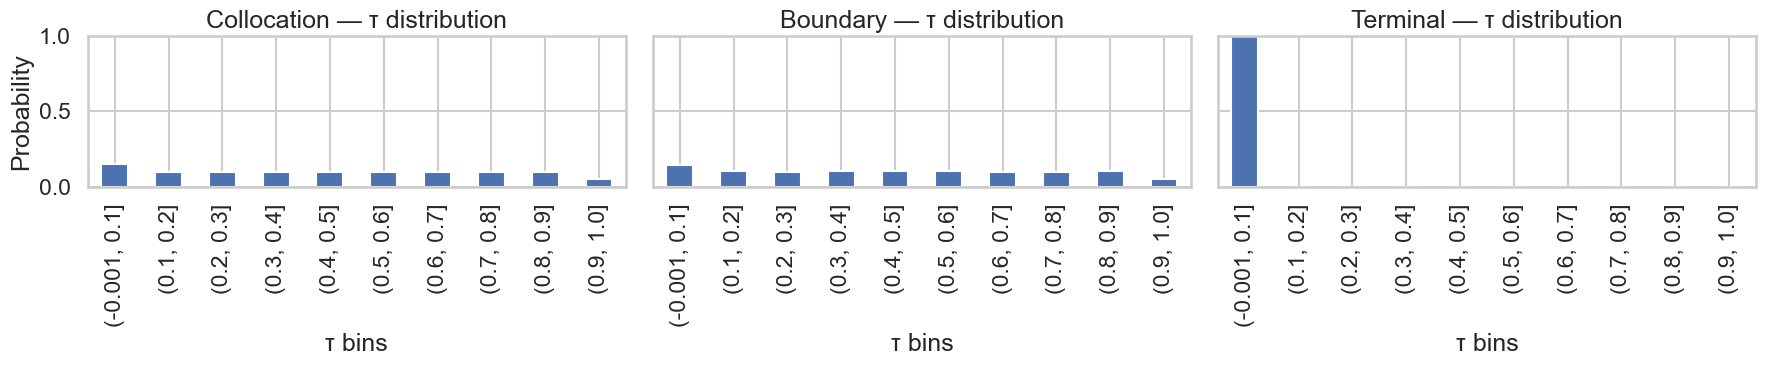

In [5]:
# τ distribution

tau_bins = np.linspace(0.0, 1.0, 11)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (name, df) in zip(axes, datasets.items()):
    tau_binned = pd.cut(df["tau"], bins=tau_bins, include_lowest=True)
    tau_dist = tau_binned.value_counts(normalize=True).sort_index()

    tau_dist.plot(kind="bar", ax=ax)
    ax.set_title(f"{name} — τ distribution")
    ax.set_xlabel("τ bins")
    ax.set_ylim(0, 1.0)

axes[0].set_ylabel("Probability")

plt.tight_layout()
plt.show()


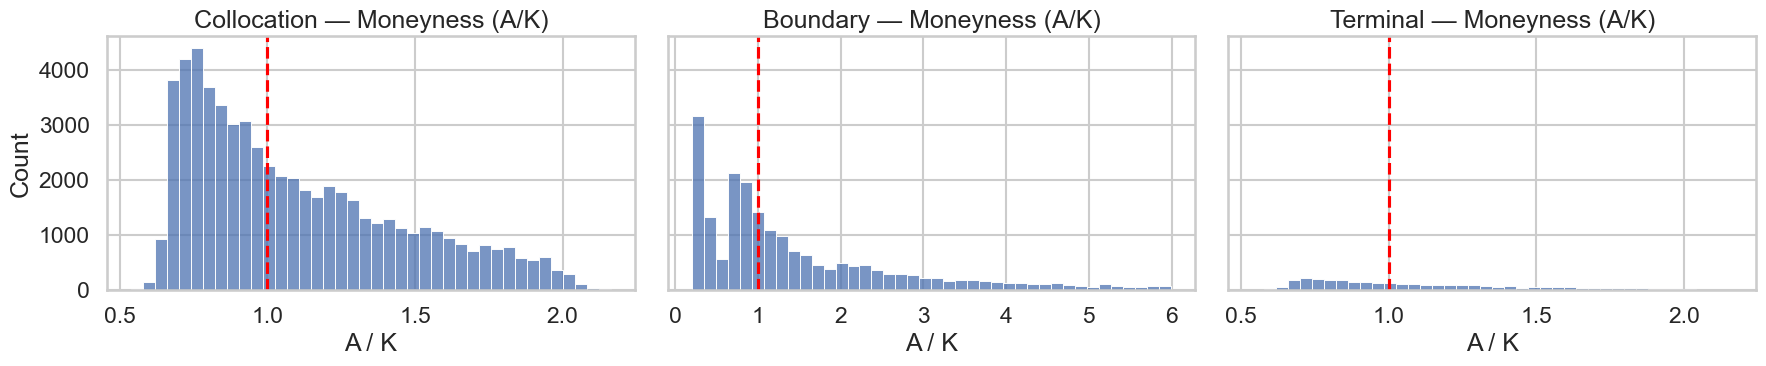

In [6]:
# MONEyness on Collocation
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (name, df) in zip(axes, datasets.items()):
    m = df["A"] / df["K"]

    sns.histplot(m, bins=40, ax=ax)
    ax.axvline(1.0, color="red", linestyle="--")
    ax.set_title(f"{name} — Moneyness (A/K)")
    ax.set_xlabel("A / K")

plt.tight_layout()
plt.show()



In [7]:
# MONEyness SPLIT (ITM / ATM / OTM)
print("MONEyness SPLIT (ITM / ATM / OTM)")

for name, df in datasets.items():
    m = df["A"] / df["K"]

    itm = (m > 1.05).mean()
    atm = ((m >= 0.95) & (m <= 1.05)).mean()
    otm = (m < 0.95).mean()

    print(f"\n{name}")
    print(f"  ITM  : {itm:6.2%}")
    print(f"  ATM  : {atm:6.2%}")
    print(f"  OTM  : {otm:6.2%}")


MONEyness SPLIT (ITM / ATM / OTM)

Collocation
  ITM  : 45.30%
  ATM  :  9.63%
  OTM  : 45.07%

Boundary
  ITM  : 47.80%
  ATM  :  4.76%
  OTM  : 47.44%

Terminal
  ITM  : 45.07%
  ATM  : 10.13%
  OTM  : 44.80%


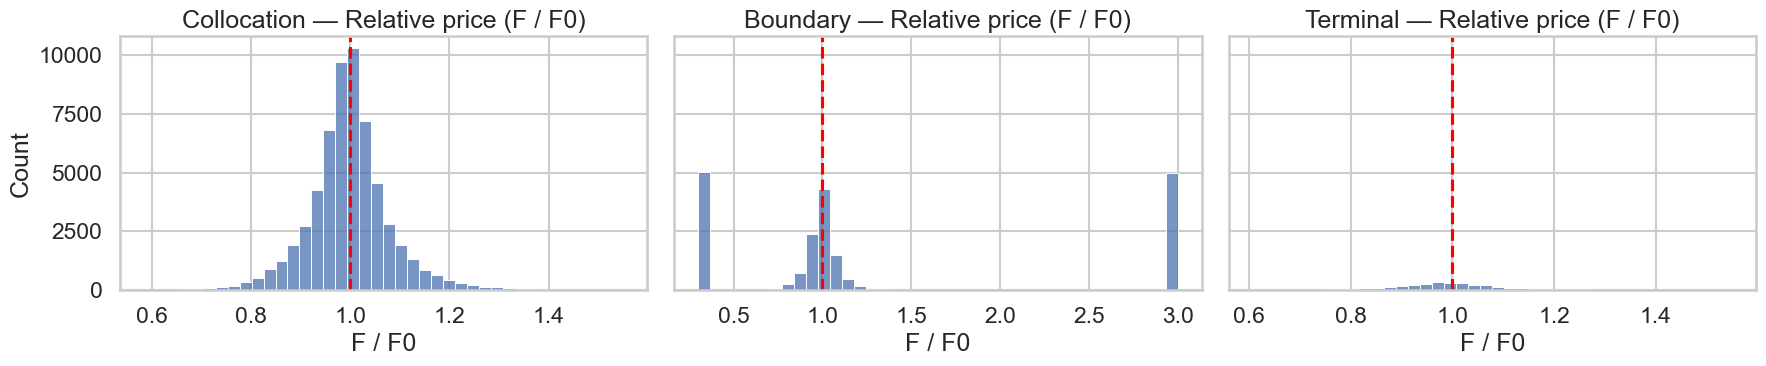

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (name, df) in zip(axes, datasets.items()):
    if "F0_ref" in df.columns:
        rel_price = df["F"] / df["F0_ref"]

        sns.histplot(rel_price, bins=40, ax=ax)
        ax.axvline(1.0, color="red", linestyle="--")

        ax.set_title(f"{name} — Relative price (F / F0)")
        ax.set_xlabel("F / F0")

plt.tight_layout()
plt.show()


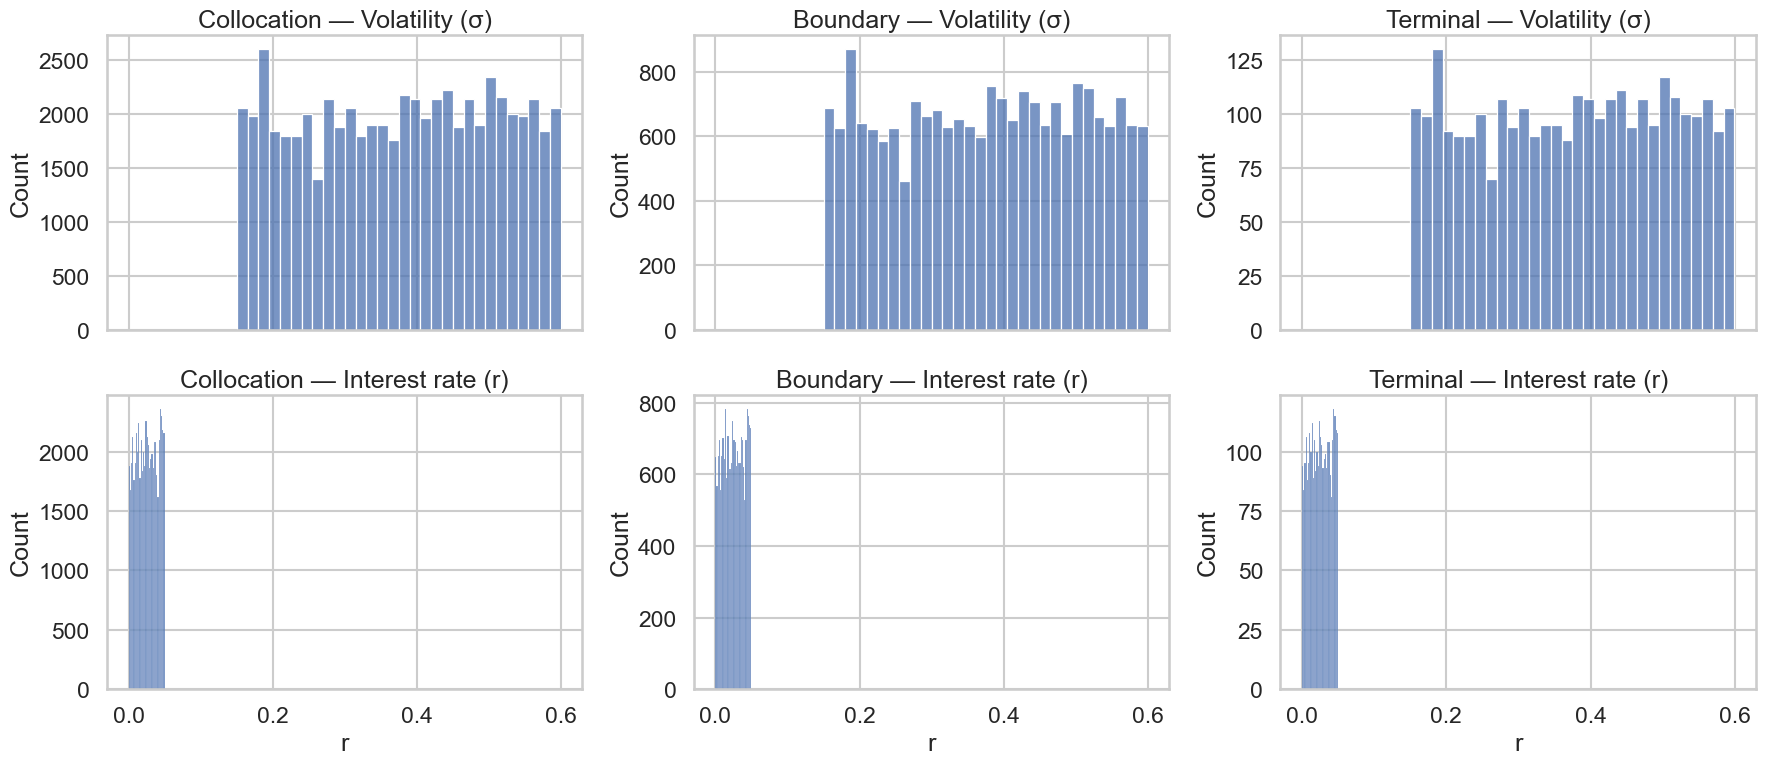

PARAMETER SPREAD (STD)

Collocation
  sigma std : 0.1305
  r std     : 0.0145

Boundary
  sigma std : 0.1300
  r std     : 0.0145

Terminal
  sigma std : 0.1305
  r std     : 0.0145


In [9]:
# PARAMETER SPREAD (STD)
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex="col")

for col_idx, (name, df) in enumerate(datasets.items()):
    sns.histplot(df["sigma"], bins=30, ax=axes[0, col_idx])
    axes[0, col_idx].set_title(f"{name} — Volatility (σ)")

    sns.histplot(df["r"], bins=30, ax=axes[1, col_idx])
    axes[1, col_idx].set_title(f"{name} — Interest rate (r)")

plt.tight_layout()
plt.show()


print("PARAMETER SPREAD (STD)")
for name, df in datasets.items():
    print(f"\n{name}")
    print(f"  sigma std : {df['sigma'].std():.4f}")
    print(f"  r std     : {df['r'].std():.4f}")


In [10]:
# COLLOCATION vs BOUNDARY COMPARISON
print("COLLOCATION vs BOUNDARY COMPARISON")

for col in ["tau", "F", "A"]:
    print(f"\nVariable: {col}")
    print(f"  Collocation mean/std : "
          f"{df_coll[col].mean():.4f} / {df_coll[col].std():.4f}")
    print(f"  Boundary    mean/std : "
          f"{df_bdry[col].mean():.4f} / {df_bdry[col].std():.4f}")


COLLOCATION vs BOUNDARY COMPARISON

Variable: tau
  Collocation mean/std : 0.4750 / 0.2883
  Boundary    mean/std : 0.4755 / 0.2875

Variable: F
  Collocation mean/std : 74.8503 / 21.0676
  Boundary    mean/std : 98.5162 / 82.2114

Variable: A
  Collocation mean/std : 74.8823 / 20.4070
  Boundary    mean/std : 98.5647 / 82.2925


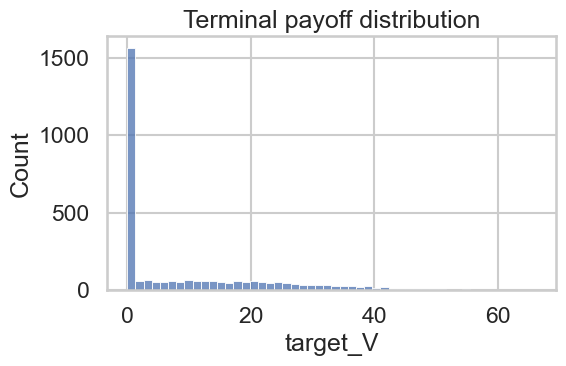

TERMINAL PAYOFF SPLIT
  Zero payoff     : 50.10%
  Positive payoff : 49.90%


In [11]:
# TERMINAL PAYOFF SPLIT
tv = df_term["target_V"]

plt.figure(figsize=(6, 4))
sns.histplot(tv, bins=50)
plt.title("Terminal payoff distribution")
plt.xlabel("target_V")
plt.tight_layout()
plt.show()

print("TERMINAL PAYOFF SPLIT")
print(f"  Zero payoff     : {(tv == 0).mean():6.2%}")
print(f"  Positive payoff : {(tv > 0).mean():6.2%}")


In [12]:
# FINAL DATASET BALANCE SCORE
score = 0

# τ coverage
if df_coll["tau"].std() > 0.25:
    score += 1

# Moneyness diversity
m = df_coll["A"] / df_coll["K"]
if (m > 1.05).mean() > 0.10 and (m < 0.95).mean() > 0.10:
    score += 1

# Parameter coverage
if df_coll["sigma"].std() > 0.10:
    score += 1

# Terminal diversity
if (tv == 0).mean() > 0.10 and (tv > 0).mean() > 0.10:
    score += 1

print("FINAL DATASET BALANCE SCORE")
print(f"Balance score: {score} / 4")


FINAL DATASET BALANCE SCORE
Balance score: 4 / 4


In [ ]:
metrics = evaluate_pinn_vs_mc(df_val, tau=0.999)
print("\nFinal metrics:", metrics)

# MLP

## MODEL TRAINING 

In [2]:


# Normalizzazione
dfc = normalize_df(df_coll)
dft = normalize_df(df_term)
dfb = normalize_df(df_bdry)

Xc_full = pack_inputs(dfc)
Xt_full = pack_inputs(dft)
Xb_full = pack_inputs(dfb)

yT = torch.tensor((df_term["target_V"].values / df_term["F0_ref"].values),
                  dtype=torch.float32, device=DEVICE).unsqueeze(1)
yB = torch.tensor((df_bdry["target_V"].values / df_bdry["F0_ref"].values),
                  dtype=torch.float32, device=DEVICE).unsqueeze(1)

model = MLP().to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
mse = nn.MSELoss()

print("Start PINN Training...")
for epoch in range(1, EPOCHS + 1):
    model.train()

    Xc, _ = minibatch(Xc_full, BATCH_C)
    Rc = pde_residual(model, Xc)
    loss_phys = torch.mean(Rc**2)

    Xt, it = minibatch(Xt_full, BATCH_T)
    pred_T = model(Xt)
    loss_term = mse(pred_T, yT[it])

    Xb, ib = minibatch(Xb_full, BATCH_B)
    pred_B = model(Xb)
    loss_bound = mse(pred_B, yB[ib])

    loss = ALPHA * loss_phys + BETA * loss_term + GAMMA * loss_bound

    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    opt.step()
    scheduler.step()

    if epoch % 200 == 0 or epoch == 1:
        print(f"[{epoch:4d}] total={loss.item():.6f}  "
              f"PDE={loss_phys.item():.6f}  term={loss_term.item():.6f}  bnd={loss_bound.item():.6f}")


Start PINN Training...
[   1] total=1.228204  PDE=0.000443  term=0.046261  bnd=1.135240
[ 200] total=0.024784  PDE=0.002273  term=0.006494  bnd=0.009522
[ 400] total=0.014789  PDE=0.001290  term=0.004274  bnd=0.004952
[ 600] total=0.004979  PDE=0.000609  term=0.001064  bnd=0.002243
[ 800] total=0.003760  PDE=0.000336  term=0.000955  bnd=0.001514
[1000] total=0.002919  PDE=0.000352  term=0.000729  bnd=0.001109
[1200] total=0.003047  PDE=0.000327  term=0.000950  bnd=0.000819
[1400] total=0.002421  PDE=0.000318  term=0.000760  bnd=0.000582
[1600] total=0.002415  PDE=0.000258  term=0.000791  bnd=0.000574
[1800] total=0.002087  PDE=0.000276  term=0.000708  bnd=0.000396
[2000] total=0.001791  PDE=0.000211  term=0.000617  bnd=0.000345
[2200] total=0.001707  PDE=0.000204  term=0.000594  bnd=0.000316
[2400] total=0.001860  PDE=0.000329  term=0.000591  bnd=0.000349
[2600] total=0.001758  PDE=0.000205  term=0.000639  bnd=0.000274
[2800] total=0.002001  PDE=0.000163  term=0.000768  bnd=0.000301
[3

## MODEL EVALUATION

GLOBAL ACCURACY → MAE = 1.3907 | RMSE = 2.1602


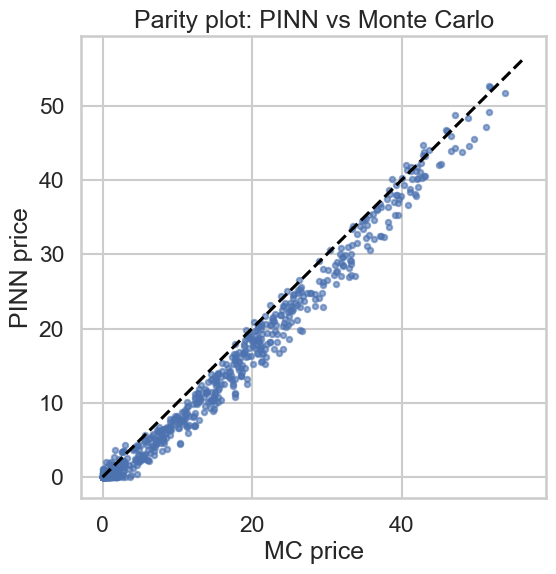

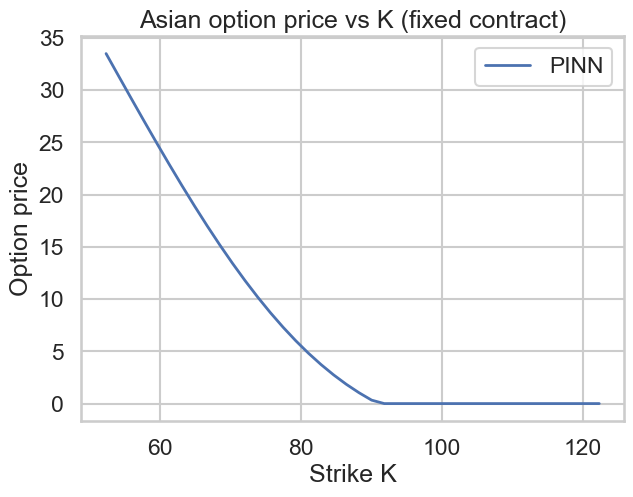

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error



model.eval()

# ============================================================
# 1) GLOBAL ACCURACY: PARITY PLOT + MAE
# ============================================================

tau = 0.999
N = len(df_val)

F0 = df_val["F0"].values
K  = df_val["K"].values
r  = df_val["r"].values
s  = df_val["sigma"].values
T  = df_val["T_years"].values

# PINN input (normalized as in training)
X = np.stack([
    np.full(N, tau),          # tau
    np.ones(N),               # F/F0 = 1
    np.ones(N),               # A/F0 = 1
    K / F0,                   # K/F0
    r,
    s,
    T
], axis=1)

X = torch.tensor(X, dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    Vn = model(X).cpu().numpy().reshape(-1)

# --- price reconstruction + positivity constraint
price_pinn = Vn * F0
price_pinn = np.maximum(price_pinn, 0.0)

price_mc = df_val["price_mc"].values

mae  = mean_absolute_error(price_mc, price_pinn)
rmse = np.sqrt(mean_squared_error(price_mc, price_pinn))

print(f"GLOBAL ACCURACY → MAE = {mae:.4f} | RMSE = {rmse:.4f}")

# Parity plot
plt.figure(figsize=(6,6))
plt.scatter(price_mc, price_pinn, s=15, alpha=0.6)
lims = [0, max(price_mc.max(), price_pinn.max()) * 1.05]
plt.plot(lims, lims, "--", color="black")
plt.xlabel("MC price")
plt.ylabel("PINN price")
plt.title("Parity plot: PINN vs Monte Carlo")
plt.grid(True)
plt.show()


# ============================================================
# 2) PRICE vs K — FIXED CONTRACT (PAPER-STYLE)
# ============================================================

row = df_val.iloc[0]
F0_ref = row["F0"]
r_ref  = row["r"]
s_ref  = row["sigma"]
T_ref  = row["T_years"]

K_grid = np.linspace(0.6 * F0_ref, 1.4 * F0_ref, 40)

Xk = np.stack([
    np.full(len(K_grid), tau),
    np.ones(len(K_grid)),
    np.ones(len(K_grid)),
    K_grid / F0_ref,
    np.full(len(K_grid), r_ref),
    np.full(len(K_grid), s_ref),
    np.full(len(K_grid), T_ref)
], axis=1)

Xk = torch.tensor(Xk, dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    Vn_k = model(Xk).cpu().numpy().reshape(-1)

# --- price reconstruction + positivity constraint
price_pinn_k = Vn_k * F0_ref
price_pinn_k = np.maximum(price_pinn_k, 0.0)

plt.figure(figsize=(7,5))
plt.plot(K_grid, price_pinn_k, linewidth=2, label="PINN")
plt.xlabel("Strike K")
plt.ylabel("Option price")
plt.title("Asian option price vs K (fixed contract)")
plt.grid(True)
plt.legend()
plt.show()


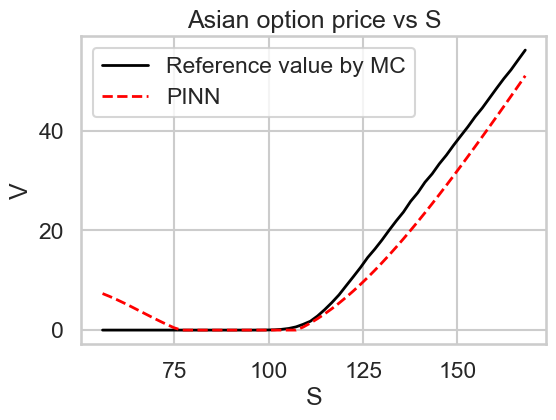

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils import make_business_calendar
# calendar used for MC and PINN
n_days, dt_years = make_business_calendar()


def price_asian_arith_mc(F0, K, r, sigma, n_days, dt_years, n_paths=8000):
    """
    Monte Carlo price of an arithmetic Asian call option.
    """
    payoff = np.zeros(n_paths)

    for i in range(n_paths):
        S = F0
        sum_S = 0.0

        for _ in range(n_days):
            Z = np.random.normal()
            S *= np.exp(
                (r - 0.5 * sigma**2) * dt_years
                + sigma * np.sqrt(dt_years) * Z
            )
            sum_S += S

        A = sum_S / n_days
        payoff[i] = max(A - K, 0.0)

    return np.exp(-r * n_days * dt_years) * payoff.mean()


model.eval()

# ----------------------------
# Fixed contract
# ----------------------------
row = df_val.iloc[0]
K = row["K"]
r = row["r"]
sigma = row["sigma"]
T = row["T_years"]

tau = 0.999
S_grid = np.linspace(0.5 * K, 1.5 * K, 60)

# ----------------------------
# PINN prices
# ----------------------------
X = np.stack([
    np.full(len(S_grid), tau),
    np.ones(len(S_grid)),              # F/F0 = 1
    np.ones(len(S_grid)),              # A/F0 = 1
    K / S_grid,                        # K/F0  (F0 = S here)
    np.full(len(S_grid), r),
    np.full(len(S_grid), sigma),
    np.full(len(S_grid), T)
], axis=1)

X = torch.tensor(X, dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    Vn = model(X).cpu().numpy().reshape(-1)

price_pinn = np.maximum(Vn * S_grid, 0.0)

# ----------------------------
# Monte Carlo prices
# ----------------------------
price_mc = np.array([
    price_asian_arith_mc(
        F0=S, K=K, r=r, sigma=sigma,
        n_days=n_days, dt_years=dt_years,
        n_paths=8000
    )
    for S in S_grid
])

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(6,4))
plt.plot(S_grid, price_mc, color="black", linewidth=2, label="Reference value by MC")
plt.plot(S_grid, price_pinn, "--", color="red", linewidth=2, label="PINN")
plt.xlabel("S")
plt.ylabel("V")
plt.title("Asian option price vs S")
plt.legend()
plt.grid(True)
plt.show()


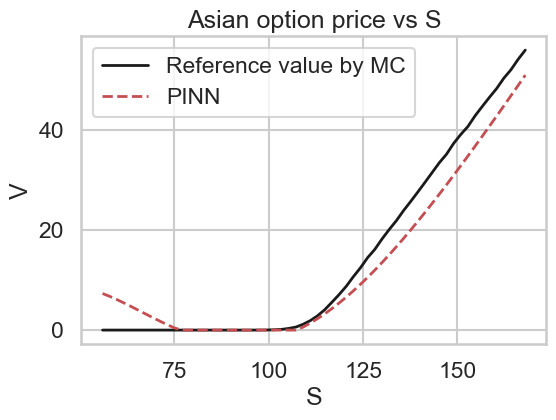

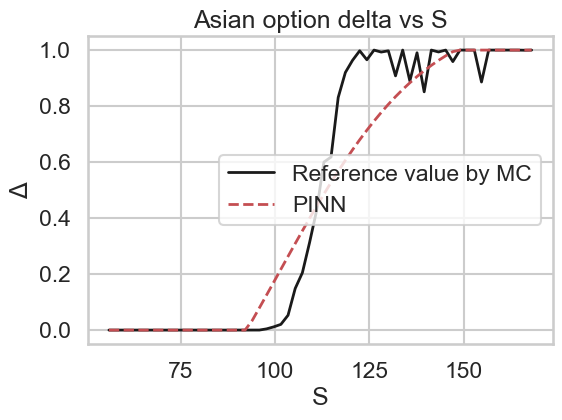

In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from utils import make_business_calendar

# ============================================================
# SETUP
# ============================================================
plt.close("all")  # evita accumulo di plot/legende se rilanci la cella

DEVICE = next(model.parameters()).device
model.eval()

n_days, dt_years = make_business_calendar()

# ============================================================
# MONTE CARLO PRICER (ASIAN ARITHMETIC CALL)
# ============================================================
def price_asian_arith_mc(F0, K, r, sigma, n_days, dt_years, n_paths=8000):
    payoff = np.zeros(n_paths)
    for i in range(n_paths):
        S = F0
        sum_S = 0.0
        for _ in range(n_days):
            Z = np.random.normal()
            S *= np.exp((r - 0.5 * sigma**2) * dt_years + sigma * np.sqrt(dt_years) * Z)
            sum_S += S
        A = sum_S / n_days
        payoff[i] = max(A - K, 0.0)
    return np.exp(-r * n_days * dt_years) * payoff.mean()

# ============================================================
# FIXED CONTRACT
# ============================================================
row = df_val.iloc[0]
K = float(row["K"])
r = float(row["r"])
sigma = float(row["sigma"])
T = float(row["T_years"])

tau = 0.999
S_grid = np.linspace(0.5 * K, 1.5 * K, 60).astype(np.float32)

# ============================================================
# PRICE PINN
# ============================================================
X_np = np.stack([
    np.full_like(S_grid, tau, dtype=np.float32),
    np.ones_like(S_grid, dtype=np.float32),
    np.ones_like(S_grid, dtype=np.float32),
    (K / S_grid).astype(np.float32),
    np.full_like(S_grid, r, dtype=np.float32),
    np.full_like(S_grid, sigma, dtype=np.float32),
    np.full_like(S_grid, T, dtype=np.float32),
], axis=1)

X = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    v = model(X).squeeze(-1).detach().cpu().numpy().reshape(-1)  # <-- FORZA 1D

price_pinn = np.maximum(v * S_grid, 0.0)

# ============================================================
# PRICE MC
# ============================================================
price_mc = np.array([
    price_asian_arith_mc(F0=float(S), K=K, r=r, sigma=sigma,
                         n_days=n_days, dt_years=dt_years, n_paths=8000)
    for S in S_grid
], dtype=float)

# ============================================================
# PLOT: PRICE vs S
# ============================================================
plt.figure(figsize=(6,4))
plt.plot(S_grid, price_mc, "k-", lw=2, label="Reference value by MC")
plt.plot(S_grid, price_pinn, "r--", lw=2, label="PINN")
plt.xlabel("S")
plt.ylabel("V")
plt.title("Asian option price vs S")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# DELTA PINN (CORRECT — CHAIN RULE)
#   V(F0) = F0 * v(x),  x = K/F0
#   Delta = dV/dF0 = v - x * dv/dx
# ============================================================
x = torch.tensor((K / S_grid), dtype=torch.float32, device=DEVICE, requires_grad=True)  # (N,)

X = torch.stack([
    torch.full_like(x, tau),
    torch.ones_like(x),
    torch.ones_like(x),
    x,
    torch.full_like(x, r),
    torch.full_like(x, sigma),
    torch.full_like(x, T),
], dim=1)  # (N,7)

v_t = model(X).squeeze(-1)  # <-- FORZA 1D: (N,)

dv_dx = torch.autograd.grad(
    outputs=v_t,
    inputs=x,
    grad_outputs=torch.ones_like(v_t),
    create_graph=False
)[0].squeeze(-1)  # <-- FORZA 1D

delta_pinn = (v_t - x * dv_dx).detach().cpu().numpy().reshape(-1)  # <-- 1D

# ============================================================
# DELTA MC (ROBUST CENTRAL DIFFERENCES)
# ============================================================
eps = 0.5  # molto più stabile di 1e-2 per MC
delta_mc = np.array([
    (price_asian_arith_mc(F0=float(S + eps), K=K, r=r, sigma=sigma,
                          n_days=n_days, dt_years=dt_years, n_paths=8000)
     - price_asian_arith_mc(F0=float(S - eps), K=K, r=r, sigma=sigma,
                            n_days=n_days, dt_years=dt_years, n_paths=8000)) / (2 * eps)
    for S in S_grid
], dtype=float)

# (opzionale) clamp fisico: Delta in [0,1] per call (utile se vuoi un grafico “paper-clean”)
delta_pinn_clipped = np.clip(delta_pinn, 0.0, 1.0)
delta_mc_clipped   = np.clip(delta_mc,   0.0, 1.0)

# ============================================================
# PLOT: DELTA vs S
# ============================================================
plt.figure(figsize=(6,4))
plt.plot(S_grid, delta_mc_clipped, "k-", lw=2, label="Reference value by MC")
plt.plot(S_grid, delta_pinn_clipped, "r--", lw=2, label="PINN")
plt.xlabel("S")
plt.ylabel("Δ")
plt.title("Asian option delta vs S")
plt.grid(True)
plt.legend()
plt.show()


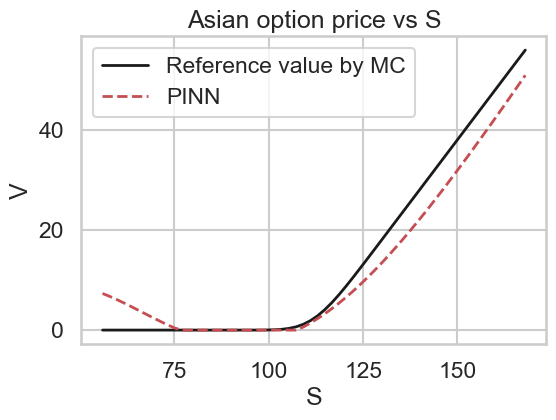

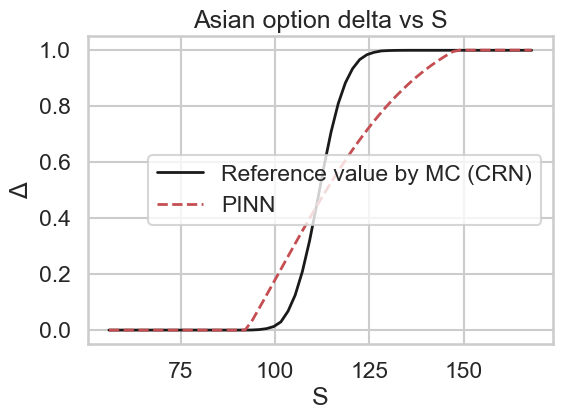

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from utils import make_business_calendar

# ============================================================
# SETUP
# ============================================================
plt.close("all")

DEVICE = next(model.parameters()).device
model.eval()

n_days, dt_years = make_business_calendar()

# ============================================================
# MONTE CARLO ASIAN PRICER (CRN-READY)
# ============================================================
def price_asian_arith_mc_crn(F0, K, r, sigma, n_days, dt_years, Z):
    """
    Arithmetic Asian call price using Common Random Numbers
    Z shape: (n_paths, n_days)
    """
    S = np.full(Z.shape[0], F0)
    sum_S = np.zeros(Z.shape[0])

    for t in range(n_days):
        S *= np.exp(
            (r - 0.5 * sigma**2) * dt_years
            + sigma * np.sqrt(dt_years) * Z[:, t]
        )
        sum_S += S

    A = sum_S / n_days
    payoff = np.maximum(A - K, 0.0)

    return np.exp(-r * n_days * dt_years) * payoff.mean()

# ============================================================
# FIXED CONTRACT
# ============================================================
row = df_val.iloc[0]
K = float(row["K"])
r = float(row["r"])
sigma = float(row["sigma"])
T = float(row["T_years"])

tau = 0.999
S_grid = np.linspace(0.5 * K, 1.5 * K, 60).astype(np.float32)

# ============================================================
# PINN PRICE
# ============================================================
X_np = np.stack([
    np.full_like(S_grid, tau),
    np.ones_like(S_grid),
    np.ones_like(S_grid),
    K / S_grid,
    np.full_like(S_grid, r),
    np.full_like(S_grid, sigma),
    np.full_like(S_grid, T),
], axis=1)

X = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    v = model(X).squeeze(-1).cpu().numpy()

price_pinn = np.maximum(v * S_grid, 0.0)

# ============================================================
# MONTE CARLO PRICE
# ============================================================
n_paths = 8000
rng = np.random.default_rng(42)
Z_price = rng.standard_normal(size=(n_paths, n_days))

price_mc = np.array([
    price_asian_arith_mc_crn(
        F0=float(S), K=K, r=r, sigma=sigma,
        n_days=n_days, dt_years=dt_years, Z=Z_price
    )
    for S in S_grid
])

# ============================================================
# PLOT PRICE vs S
# ============================================================
plt.figure(figsize=(6,4))
plt.plot(S_grid, price_mc, "k-", lw=2, label="Reference value by MC")
plt.plot(S_grid, price_pinn, "r--", lw=2, label="PINN")
plt.xlabel("S")
plt.ylabel("V")
plt.title("Asian option price vs S")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# DELTA PINN (CORRECT — CHAIN RULE)
#   V(F0) = F0 * v(x),  x = K/F0
#   Delta = v - x * dv/dx
# ============================================================
x = torch.tensor(
    K / S_grid,
    dtype=torch.float32,
    device=DEVICE,
    requires_grad=True
)

X = torch.stack([
    torch.full_like(x, tau),
    torch.ones_like(x),
    torch.ones_like(x),
    x,
    torch.full_like(x, r),
    torch.full_like(x, sigma),
    torch.full_like(x, T),
], dim=1)

v_t = model(X).squeeze(-1)

dv_dx = torch.autograd.grad(
    outputs=v_t,
    inputs=x,
    grad_outputs=torch.ones_like(v_t),
    create_graph=False
)[0]

delta_pinn = (v_t - x * dv_dx).detach().cpu().numpy()

# ============================================================
# DELTA MONTE CARLO (CRN + CENTRAL DIFFERENCES)
# ============================================================
eps = 0.5
Z_delta = rng.standard_normal(size=(n_paths, n_days))

delta_mc = np.array([
    (
        price_asian_arith_mc_crn(
            F0=float(S + eps), K=K, r=r, sigma=sigma,
            n_days=n_days, dt_years=dt_years, Z=Z_delta
        )
        -
        price_asian_arith_mc_crn(
            F0=float(S - eps), K=K, r=r, sigma=sigma,
            n_days=n_days, dt_years=dt_years, Z=Z_delta
        )
    ) / (2 * eps)
    for S in S_grid
])

# (opzionale, solo per visual pulito)
delta_pinn = np.clip(delta_pinn, 0.0, 1.0)
delta_mc   = np.clip(delta_mc,   0.0, 1.0)

# ============================================================
# PLOT DELTA vs S
# ============================================================
plt.figure(figsize=(6,4))
plt.plot(S_grid, delta_mc, "k-", lw=2, label="Reference value by MC (CRN)")
plt.plot(S_grid, delta_pinn, "r--", lw=2, label="PINN")
plt.xlabel("S")
plt.ylabel("Δ")
plt.title("Asian option delta vs S")
plt.grid(True)
plt.legend()
plt.show()


In [21]:
# Evaluation

def price_asian_pinn(F0, K, r, sigma, T_years, tau=0.999, A0=None):
    if A0 is None:
        A0 = F0
    x = torch.tensor([[tau, F0/F0, A0/F0, K/F0, r, sigma, T_years]],
                     dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        Vn = model(x).item()
    return Vn * F0

def pinn_price_batch(df, tau=0.999):
    model.eval()
    with torch.no_grad():
        F0 = df["F0"].values.astype(np.float32)
        K  = df["K"].values.astype(np.float32)
        r  = df["r"].values.astype(np.float32)
        s  = df["sigma"].values.astype(np.float32)
        T  = df["T_years"].values.astype(np.float32)
        A0 = F0.copy()

        X = np.stack([
            np.full_like(F0, tau, dtype=np.float32),
            F0 / F0,
            A0 / F0,
            K  / F0,
            r, s, T
        ], axis=1)
        X = torch.tensor(X, dtype=torma scusa non va valutato a tau = ch.float32, device=DEVICE)
        Vn = model(X).cpu().numpy().reshape(-1)
        V  = Vn * F0
        return V

def evaluate_pinn_vs_mc(df_val, tau=0.999, sample_for_curve=300):
    price_pinn = pinn_price_batch(df_val, tau=tau)
    price_mc   = df_val["price_mc"].values.astype(np.float32)

    mae  = mean_absolute_error(price_mc, price_pinn)
    mse  = mean_squared_error(price_mc, price_pinn)
    rmse = np.sqrt(mse)
    r2   = r2_score(price_mc, price_pinn)
    print(f"\nVAL – MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")

    # Parity plot
    plt.figure(figsize=(6,6))
    plt.scatter(price_mc, price_pinn, s=12, alpha=0.5)
    lims = [0, max(price_mc.max(), price_pinn.max()) * 1.05]
    plt.plot(lims, lims, linestyle="--")
    plt.xlim(lims); plt.ylim(lims)
    plt.xlabel("MC price")
    plt.ylabel("PINN price")
    plt.title("Parity plot: PINN vs Monte Carlo (balanced validation)")
    plt.grid(True)
    plt.show()

    # Curva prezzo vs K a F0 ~ costante
    f0_med = df_val["F0"].median()
    tol = max(1, 1 * f0_med)
    sub = df_val[df_val["F0"].between(f0_med - tol, f0_med + tol)].copy()
    if len(sub) > sample_for_curve:
        sub = sub.sample(sample_for_curve, random_state=42)
    sub = sub.sort_values("K")
    sub_pinn = pinn_price_batch(sub, tau=tau)

    plt.figure(figsize=(7,5))
    plt.plot(sub["K"].values, sub_pinn, label="PINN", linewidth=2)
    plt.scatter(sub["K"].values, sub["price_mc"].values, s=12, alpha=0.7, label="MC")
    plt.xlabel("Strike K")
    plt.ylabel("Option price")
    plt.title(f"Price vs K  (F0 ≈ {f0_med:.2f})")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {"MAE":mae, "RMSE":rmse, "R2":r2}

# 9) RUN VALUTAZIONE

metrics = evaluate_pinn_vs_mc(df_val, tau=0.999)
print("\nMetriche finali:", metrics)


SyntaxError: invalid syntax. Perhaps you forgot a comma? (3036832232.py, line 29)

# RESBLOCK

In [14]:
from RESPINN import ResPINN 

# Normalizzazione
dfc = normalize_df(df_coll)
dft = normalize_df(df_term)
dfb = normalize_df(df_bdry)

Xc_full = pack_inputs(dfc)
Xt_full = pack_inputs(dft)
Xb_full = pack_inputs(dfb)

yT = torch.tensor((df_term["target_V"].values / df_term["F0_ref"].values),
                  dtype=torch.float32, device=DEVICE).unsqueeze(1)
yB = torch.tensor((df_bdry["target_V"].values / df_bdry["F0_ref"].values),
                  dtype=torch.float32, device=DEVICE).unsqueeze(1)

model = ResPINN(in_dim=7).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
mse = nn.MSELoss()

EPOCHS = 600

print("Start PINN Training...")
for epoch in range(1, EPOCHS + 1):
    model.train()

    Xc, _ = minibatch(Xc_full, BATCH_C)
    Rc = pde_residual(model, Xc)
    loss_phys = torch.mean(Rc**2)

    Xt, it = minibatch(Xt_full, BATCH_T)
    pred_T = model(Xt)
    loss_term = mse(pred_T, yT[it])

    Xb, ib = minibatch(Xb_full, BATCH_B)
    pred_B = model(Xb)
    loss_bound = mse(pred_B, yB[ib])

    loss = ALPHA * loss_phys + BETA * loss_term + GAMMA * loss_bound

    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    opt.step()
    scheduler.step()

    if epoch % 200 == 0 or epoch == 1:
        print(f"[{epoch:4d}] total={loss.item():.6f}  "
              f"PDE={loss_phys.item():.6f}  term={loss_term.item():.6f}  bnd={loss_bound.item():.6f}")


Start PINN Training...
[   1] total=1.292694  PDE=0.011760  term=0.062358  bnd=1.156219
[ 200] total=0.005191  PDE=0.000466  term=0.001770  bnd=0.001185
[ 400] total=0.003201  PDE=0.000204  term=0.000928  bnd=0.001142
[ 600] total=0.002103  PDE=0.000233  term=0.000694  bnd=0.000482


## MODEL EVALUATION


VAL – MAE=1.3654  RMSE=1.7534  R²=0.9824


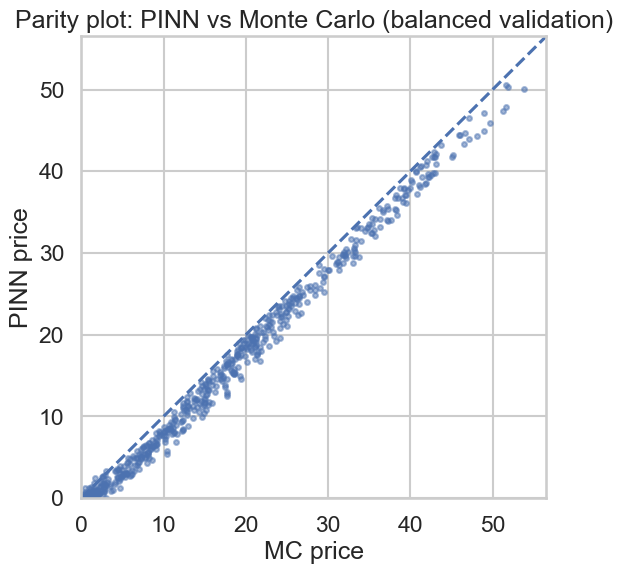

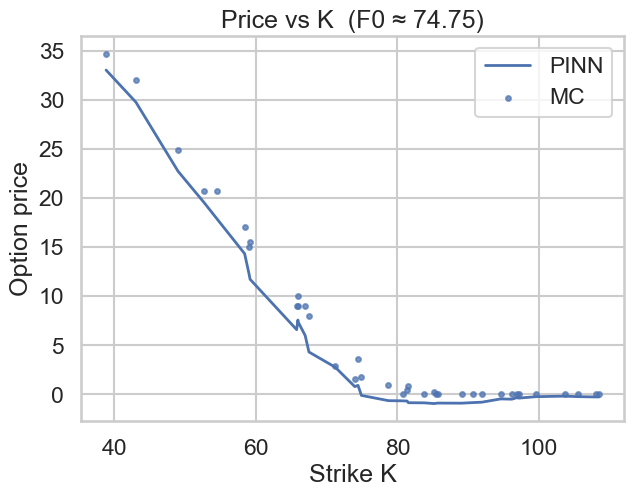


Metriche finali: {'MAE': 1.3654496669769287, 'RMSE': 1.7534113060302263, 'R2': 0.9824179410934448}


In [15]:
# Evaluation

def price_asian_pinn(F0, K, r, sigma, T_years, tau=0.999, A0=None):
    if A0 is None:
        A0 = F0
    x = torch.tensor([[tau, F0/F0, A0/F0, K/F0, r, sigma, T_years]],
                     dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        Vn = model(x).item()
    return Vn * F0

def pinn_price_batch(df, tau=0.999):
    model.eval()
    with torch.no_grad():
        F0 = df["F0"].values.astype(np.float32)
        K  = df["K"].values.astype(np.float32)
        r  = df["r"].values.astype(np.float32)
        s  = df["sigma"].values.astype(np.float32)
        T  = df["T_years"].values.astype(np.float32)
        A0 = F0.copy()

        X = np.stack([
            np.full_like(F0, tau, dtype=np.float32),
            F0 / F0,
            A0 / F0,
            K  / F0,
            r, s, T
        ], axis=1)
        X = torch.tensor(X, dtype=torch.float32, device=DEVICE)
        Vn = model(X).cpu().numpy().reshape(-1)
        V  = Vn * F0
        return V

def evaluate_pinn_vs_mc(df_val, tau=0.999, sample_for_curve=300):
    price_pinn = pinn_price_batch(df_val, tau=tau)
    price_mc   = df_val["price_mc"].values.astype(np.float32)

    mae  = mean_absolute_error(price_mc, price_pinn)
    mse  = mean_squared_error(price_mc, price_pinn)
    rmse = np.sqrt(mse)
    r2   = r2_score(price_mc, price_pinn)
    print(f"\nVAL – MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")

    # Parity plot
    plt.figure(figsize=(6,6))
    plt.scatter(price_mc, price_pinn, s=12, alpha=0.5)
    lims = [0, max(price_mc.max(), price_pinn.max()) * 1.05]
    plt.plot(lims, lims, linestyle="--")
    plt.xlim(lims); plt.ylim(lims)
    plt.xlabel("MC price")
    plt.ylabel("PINN price")
    plt.title("Parity plot: PINN vs Monte Carlo (balanced validation)")
    plt.grid(True)
    plt.show()

    # Curva prezzo vs K a F0 ~ costante
    f0_med = df_val["F0"].median()
    tol = max(0.5, 0.02 * f0_med)
    sub = df_val[df_val["F0"].between(f0_med - tol, f0_med + tol)].copy()
    if len(sub) > sample_for_curve:
        sub = sub.sample(sample_for_curve, random_state=42)
    sub = sub.sort_values("K")
    sub_pinn = pinn_price_batch(sub, tau=tau)

    plt.figure(figsize=(7,5))
    plt.plot(sub["K"].values, sub_pinn, label="PINN", linewidth=2)
    plt.scatter(sub["K"].values, sub["price_mc"].values, s=12, alpha=0.7, label="MC")
    plt.xlabel("Strike K")
    plt.ylabel("Option price")
    plt.title(f"Price vs K  (F0 ≈ {f0_med:.2f})")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {"MAE":mae, "RMSE":rmse, "R2":r2}

# 9) RUN VALUTAZIONE

metrics = evaluate_pinn_vs_mc(df_val, tau=0.999)
print("\nMetriche finali:", metrics)


In [12]:
df_val.columns

Index(['F0', 'K', 'r', 'sigma', 'T_years', 'price_mc'], dtype='object')